In [14]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.expand_frame_repr', False)

In [18]:
train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

print('Train Shape: ', train.shape)
print('Store Shape: ', store.shape)

print('------train-------')
print(train.head())
print('\n')
print(train.dtypes)
print('\n')
print('Null Values: \n', train.isnull().sum())
print('\n')

print('------store-------')
print(store.head())
print('\n')
print(store.dtypes)
print('\n')
print('Null Values: \n', store.isnull().sum())



C:\Users\vishu\AppData\Local\Temp\ipykernel_9356\1983583850.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])


Train Shape:  (1017209, 9)
Store Shape:  (1115, 10)
------train-------
   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  SchoolHoliday
0      1          5 2015-07-31   5263        555     1      1            0              1
1      2          5 2015-07-31   6064        625     1      1            0              1
2      3          5 2015-07-31   8314        821     1      1            0              1
3      4          5 2015-07-31  13995       1498     1      1            0              1
4      5          5 2015-07-31   4822        559     1      1            0              1


Store                     int64
DayOfWeek                 int64
Date             datetime64[us]
Sales                     int64
Customers                 int64
Open                      int64
Promo                     int64
StateHoliday             object
SchoolHoliday             int64
dtype: object


Null Values: 
 Store            0
DayOfWeek        0
Date             0
Sales      

> 544 out of 1,115 stores (~49%) don't participate in Promo2. The nulls in Promo2 columns are not missing data, they're a feature.

> 3 out of 1,115 stores either have no competition or it's unknown. It's small enough to be filled with median data.

> 354 out of 1,115 stores have no information about their competitors. We'll handle them with a placeholder.

In [19]:
data = pd.merge(train, store, on='Store', how='left')

print('Data Shape After Merge: ', data.shape)
print('\nNull Values After Merge: \n', data.isnull().sum())

Data Shape After Merge:  (1017209, 18)

Null Values After Merge: 
 Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64


> Extra nulls after merge are expected as they're the store-level nulls from store.csv broadcast across all rows for those stores. No new data quality issues introduced by the join. (1017209 total sales records; 1115 distinct stores; thus (1017209/1115) = ~912 records per store)

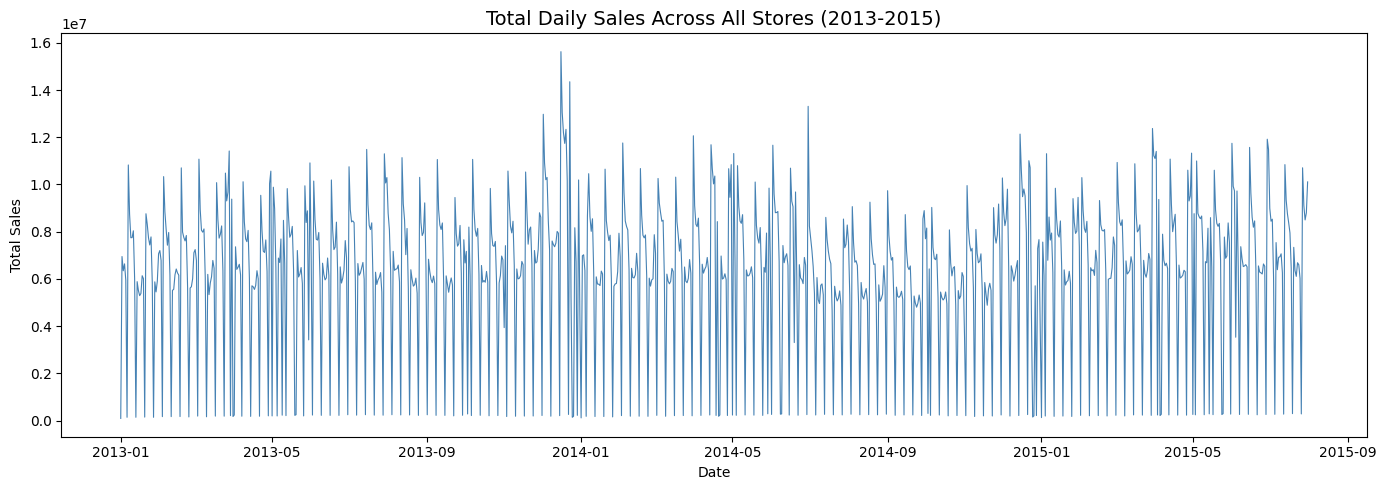

Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


In [20]:
daily_sales = data.groupby('Date')['Sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(daily_sales['Date'], daily_sales['Sales'], linewidth=0.8, color='steelblue')

ax.set_title('Total Daily Sales Across All Stores (2013-2015)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('../outputs/figures/01_daily_sales_trend.png', dpi=150)
plt.show()

print("Date range:", data['Date'].min(), 'to', data['Date'].max())

> The dominant visual pattern is weekly as most stores close on Sundays, driving sales to near-zero. This makes closed-store filtering critical in preprocessing. Plotting raw aggregated sales without filtering closed days produces a misleading "noisy" series.

In [21]:
# Confirming sunday sales are zero
print(data.groupby('DayOfWeek')['Sales'].mean().round(0))

DayOfWeek
1    7809.0
2    7005.0
3    6556.0
4    6248.0
5    6723.0
6    5848.0
7     204.0
Name: Sales, dtype: float64


> Day of week is one of the strongest features in this dataset. Monday is peak, Sunday is near-zero (store closures). This weekly pattern must be captured by any model, it's not optional.

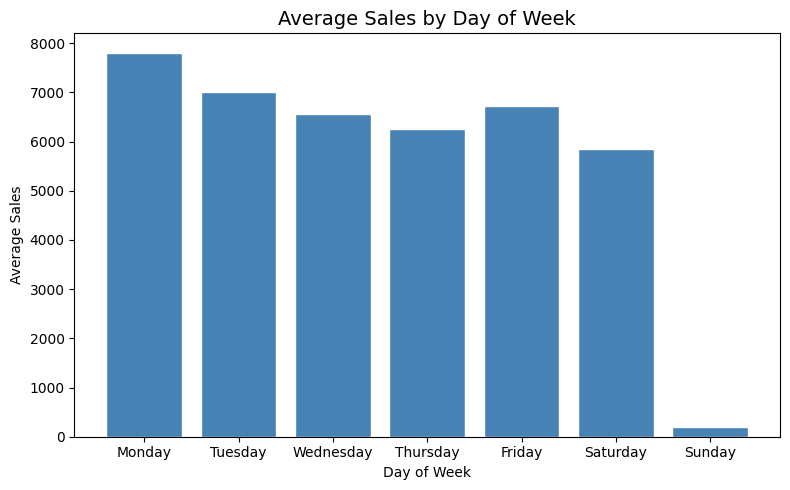

In [22]:
dayofweek_labels = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_sales = data.groupby('DayOfWeek')['Sales'].mean()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(dayofweek_labels, dow_sales.values, color='steelblue', edgecolor='white')

ax.set_title('Average Sales by Day of Week', fontsize=14)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('../outputs/figures/02_dow_sales.png', dpi=150)
plt.show()


> Weekly pattern: 

Monday peak → gradual decline → Friday recovery → Saturday drop → Sunday near-zero. Friday bump likely reflects end-of-week consumer behavior. DayOfWeek will be one of the most important features in the model.

Promo
0    5911.630026
1    8228.281239
Name: Sales, dtype: float64


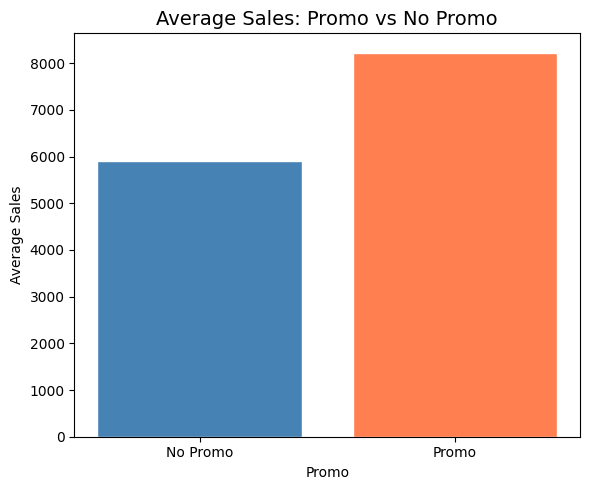

In [23]:
data_open = data[(data['Open'] == 1) & (data['DayOfWeek'] != 7)]

promo_sales = data_open.groupby('Promo')['Sales'].mean()
print(promo_sales)

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(['No Promo', 'Promo'], promo_sales.values, color=['steelblue', 'coral'], edgecolor='white')

ax.set_title('Average Sales: Promo vs No Promo', fontsize=14)
ax.set_xlabel('Promo')
ax.set_ylabel('Average Sales')
plt.tight_layout()
plt.savefig('../outputs/figures/03_promo_sales.png', dpi=150)
plt.show()

> Promo days generate ~38% higher average sales than non-promo days OR promo days do ~1.4x sales of non-promo days(open stores only). Promo is a high-signal feature so expect it near the top of feature importance plots.

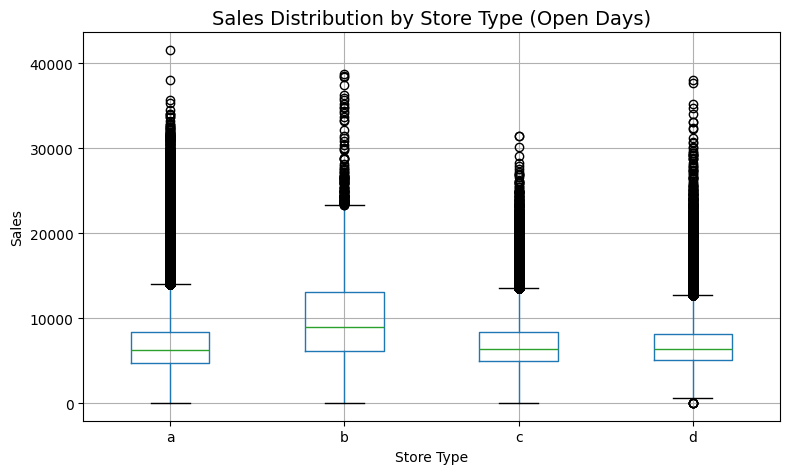

StoreType
a     6935.0
b    10029.0
c     6933.0
d     6826.0
Name: Sales, dtype: float64


In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

data_open.boxplot(column='Sales', by='StoreType', ax=ax)

ax.set_title('Sales Distribution by Store Type (Open Days)', fontsize=14)
ax.set_xlabel('Store Type')
ax.set_ylabel('Sales')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../outputs/figures/04_sales_by_storetype.png', dpi=150)
plt.show()

print(data_open.groupby('StoreType')['Sales'].mean().round(0))

> Store type b is a clear outlier having 45% higher mean sales than a, c, d. Likely a larger or flagship format. Store type is a meaningful categorical feature. a, c, d behave similarly.

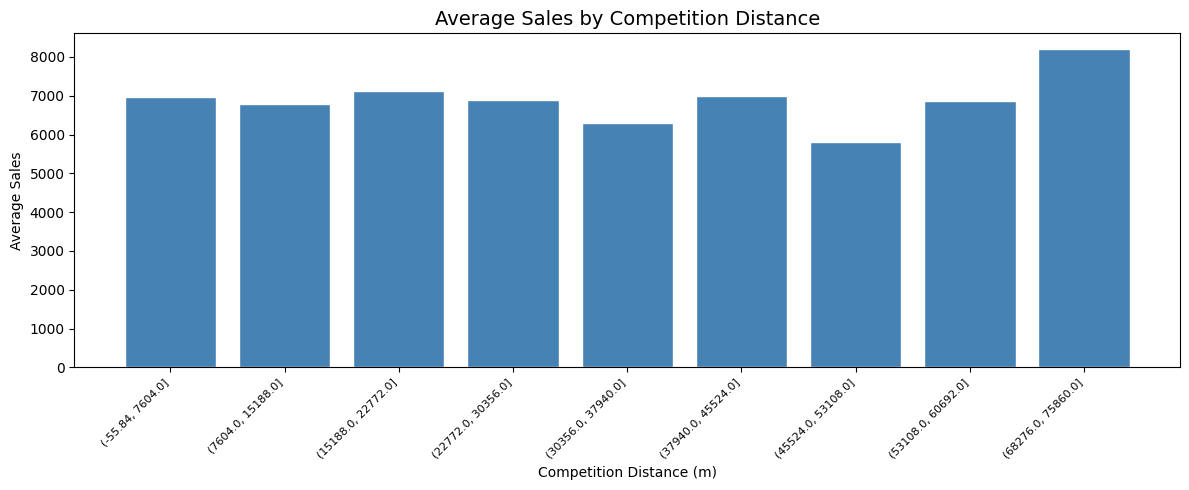

In [25]:
data_com = data_open.dropna(subset=['CompetitionDistance'])

data_com = data_com.copy()
data_com['CDBin'] = pd.cut(data_com['CompetitionDistance'], bins=10)

com_sales = data_com.groupby('CDBin')['Sales'].mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(range(len(com_sales)), com_sales.values, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(com_sales)))
ax.set_xticklabels([str(b) for b in com_sales.index], rotation=45, ha='right', fontsize=8)

ax.set_title('Average Sales by Competition Distance', fontsize=14)
ax.set_xlabel('Competition Distance (m)')
ax.set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('../outputs/figures/05_sales_by_competition_distance.png', dpi=150)
plt.show()

> Competition distance shows no strong linear relationship with sales. The far-distance spike is likely a small-sample artifact. This feature may have weak standalone predictive power but could still contribute in a tree-based model combined with other features.

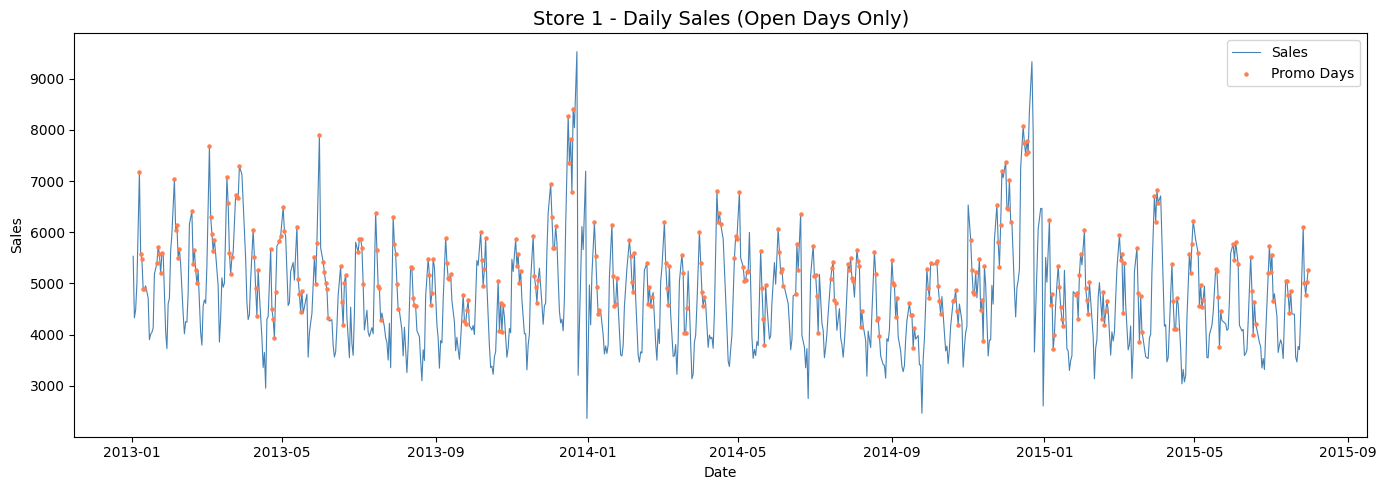

Store 1 open days: 781
Store 1 promo days: 350
Store 1 avg sales: 4759.0
Store 1 avg sales on promo: 5300.0
Store 1 avg sales no promo: 4320.0


In [26]:
st1 = data[(data['Store'] == 1) & (data['Open'] == 1)].sort_values('Date')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(st1['Date'], st1['Sales'], linewidth=0.8, color='steelblue', label='Sales')

pr_days = st1[st1['Promo'] == 1]
ax.scatter(pr_days['Date'], pr_days['Sales'], color='coral', label='Promo Days', s=5, zorder=3)
ax.set_title('Store 1 - Daily Sales (Open Days Only)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Sales')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/06_store1_sales.png', dpi=150)
plt.show()

print("Store 1 open days:", len(st1))
print("Store 1 promo days:", st1['Promo'].sum())
print("Store 1 avg sales:", st1['Sales'].mean().round(0))
print("Store 1 avg sales on promo:", st1[st1['Promo']==1]['Sales'].mean().round(0))
print("Store 1 avg sales no promo:", st1[st1['Promo']==0]['Sales'].mean().round(0))

> Store 1 shows clear yearly seasonality (Christmas peaks ~2x normal) and weekly oscillation. Promo days cluster at peaks 23% lift at store level vs 38% aggregate. Yearly seasonality must be captured via month/week features.